# Clustering from fingerprints
We will try:
* KMeans
* Butina

In [4]:
import pandas as pd
from numpy.ma.extras import column_stack

df = pd.read_csv('../my_data/structures_best.csv', usecols=['Canonical_SMILES', 'Source'])
df

,Canonical_SMILES,Source
0,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...,DrugBank
1,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DrugBank
2,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...,DrugBank
3,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DrugBank
4,C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...,DrugBank
...,...,...
18891,CCc1ncc(C(=O)NCC2CCC(NC(=O)c3ncncc3N)CC2)s1,ZINC
18892,O=C(N[C@]12CCC[C@@H]1N(C[C@@H]1CCCCO1)CC2)c1cc...,ZINC
18893,Cc1ocnc1C(=O)Nc1cccc(CNC(=O)[C@H](C)n2ccc(C3CC...,ZINC
18894,CC(C)(CF)C(=O)N1CC2(CC[C@H](CNC(=O)c3ccnc(Cl)c...,ZINC


In [6]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.cluster import KMeans

# 1. Generate RDKit molecules from SMILES
mols = [Chem.MolFromSmiles(s) for s in df['Canonical_SMILES']]

# 2. Setup the Morgan (ECFP4) Generator
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 3. Compute fingerprints and convert to a list/array
fps = [mfpgen.GetFingerprintAsNumPy(m) for m in mols]

# 4. Perform KMeans Clustering
num_clusters = 5  # Adjust as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
df['Cluster'] = kmeans.fit_predict(fps)


                                    Canonical_SMILES    Source  \
0  CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...  DrugBank   
1  CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...  DrugBank   
2  N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]1...  DrugBank   
3  CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...  DrugBank   
4  C/C=C/C[C@@H](C)[C@@H](O)[C@H]1C(=O)N[C@@H](CC...  DrugBank   

                                                  fp  Cluster  
0  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...        4  
1  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...        4  
2  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...        4  
3  [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...        4  
4  [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...        4  


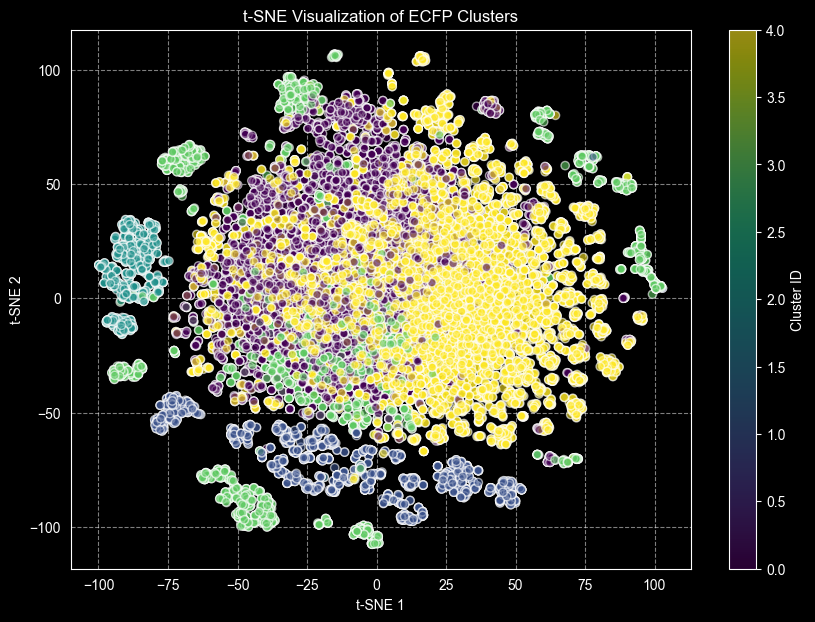

In [7]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(np.array(fps))

df['tsne_1'] = coords[:, 0]
df['tsne_2'] = coords[:, 1]

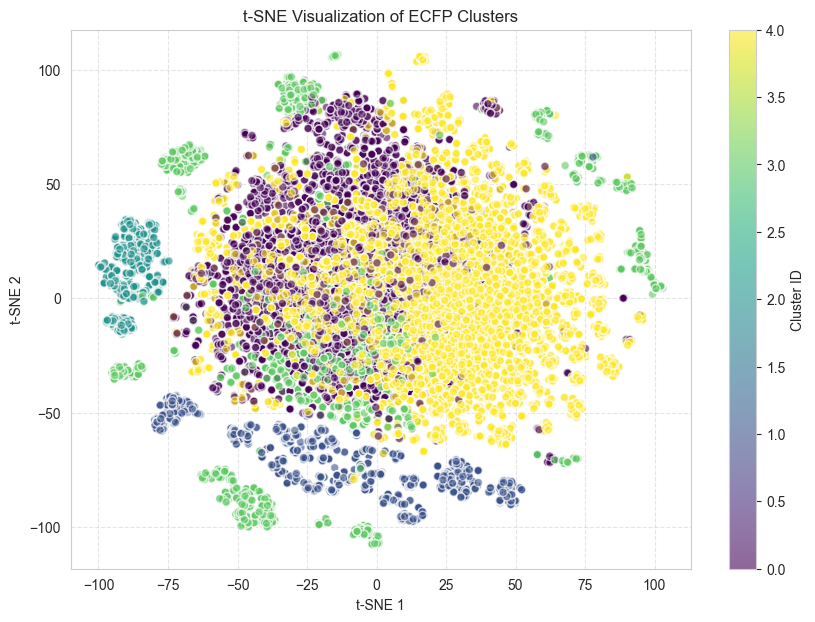

In [9]:
import seaborn as sns
sns.set_style('whitegrid')

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df['tsne_1'],
    df['tsne_2'],
    c=df['Cluster'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w'
)

plt.colorbar(scatter, label='Cluster ID')
plt.title('t-SNE Visualization of ECFP Clusters')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Now we will try Butina.

In [11]:
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina

# 1. Generate BitVect fingerprints (Required for Tanimoto/Butina)
fps_bv = [mfpgen.GetFingerprint(m) for m in mols]

def cluster_mols(fps, cutoff=0.4):
    dists = []
    nfps = len(fps)
    for i in range(1, nfps):
        # This now receives RDKit objects, matching the C++ signature
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1 - x for x in sims])

    # Perform Butina clustering
    clusters = Butina.ClusterData(dists, nfps, cutoff, isDistData=True)
    return clusters

# 2. Execute
clusters = cluster_mols(fps_bv, cutoff=0.4)

# 3. Map back to DataFrame
cluster_id_map = {}
for cluster_idx, mol_indices in enumerate(clusters):
    for mol_idx in mol_indices:
        cluster_id_map[mol_idx] = cluster_idx

df['Butina_Cluster'] = df.index.map(cluster_id_map)

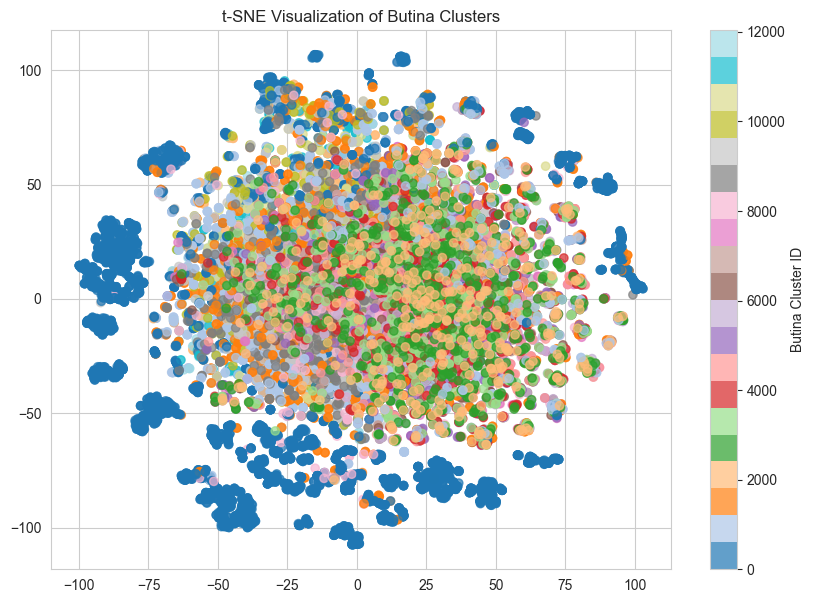

In [12]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Use the same t-SNE coordinates from before, or recalculate if needed
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
coords = tsne.fit_transform(np.array(fps)) # Using the numpy fingerprints

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=df['Butina_Cluster'],
    cmap='tab20', # 'tab20' handles more clusters better than viridis
    alpha=0.7
)

plt.colorbar(scatter, label='Butina Cluster ID')
plt.title('t-SNE Visualization of Butina Clusters')
plt.show()